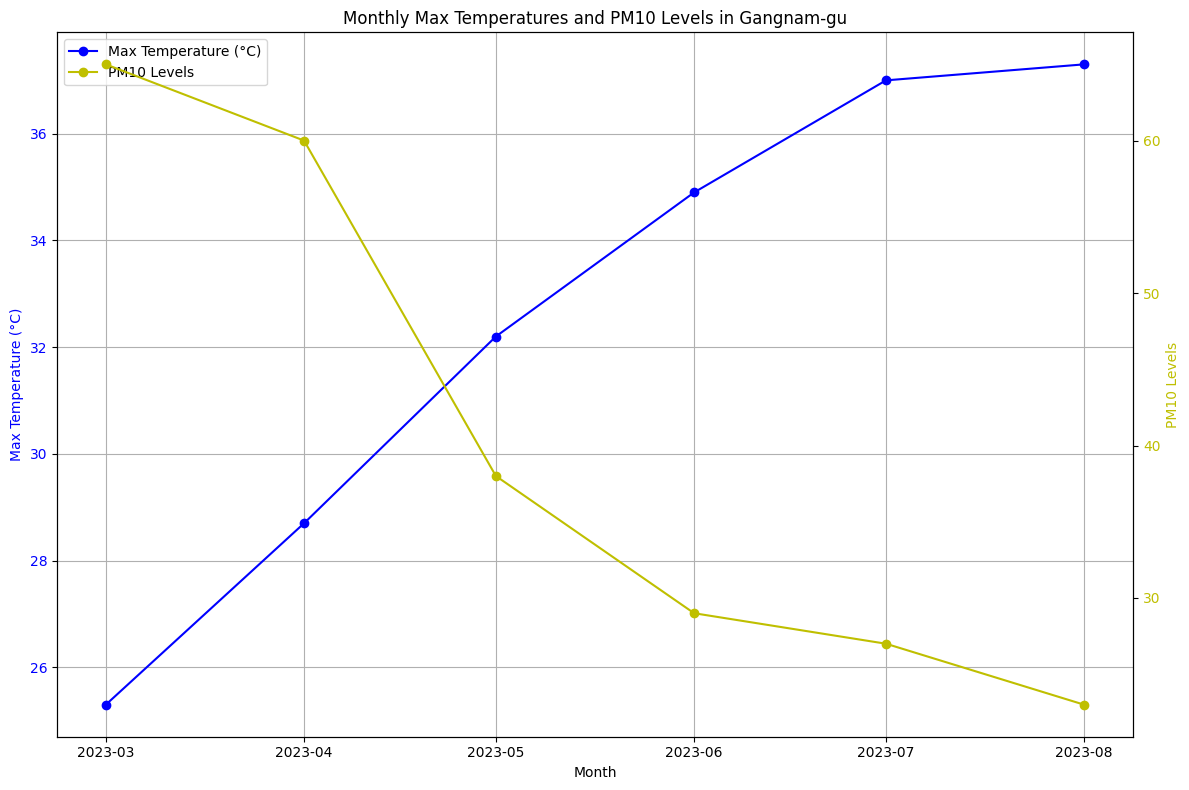

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV files
gangnam_df = pd.read_csv('./강남구.csv')
pm_df = pd.read_csv('./converted_미세먼지.csv')

# Process the temperature data
gangnam_df['날짜'] = pd.to_datetime(gangnam_df['날짜'])
gangnam_df['YearMonth'] = gangnam_df['날짜'].dt.to_period('M')
monthly_max_temp = gangnam_df.groupby('YearMonth')['최고기온'].max().reset_index()
monthly_max_temp['YearMonth'] = monthly_max_temp['YearMonth'].astype(str)
monthly_max_temp['YearMonth'] = pd.to_datetime(monthly_max_temp['YearMonth'])

# Extract relevant columns for 강남구 from the 미세먼지 dataframe
gangnam_pm_df = pm_df[pm_df['구분(3)'] == '강남구']
gangnam_pm_df = gangnam_pm_df.drop(columns=['구분(1)', '구분(2)', '구분(3)', '구분(4)'])
gangnam_pm_df = gangnam_pm_df.melt(var_name='Month', value_name='PM10')
gangnam_pm_df['PM10'] = pd.to_numeric(gangnam_pm_df['PM10'].str.replace('*', ''), errors='coerce')
gangnam_pm_df['Month'] = pd.to_datetime(gangnam_pm_df['Month'], format='%Y.%m')
gangnam_pm_df.set_index('Month', inplace=True)

# Create the combined plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plotting the temperature data
ax1.plot(monthly_max_temp['YearMonth'], monthly_max_temp['최고기온'], marker='o', linestyle='-', color='b', label='Max Temperature (°C)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Max Temperature (°C)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Creating a second y-axis for the PM10 data
ax2 = ax1.twinx()
ax2.plot(gangnam_pm_df.index, gangnam_pm_df['PM10'], marker='o', linestyle='-', color='y', label='PM10 Levels')
ax2.set_ylabel('PM10 Levels', color='y')
ax2.tick_params(axis='y', labelcolor='y')

# Adding title and grid
plt.title('Monthly Max Temperatures and PM10 Levels in Gangnam-gu')
ax1.grid(True)

# Adding legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()


/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.1

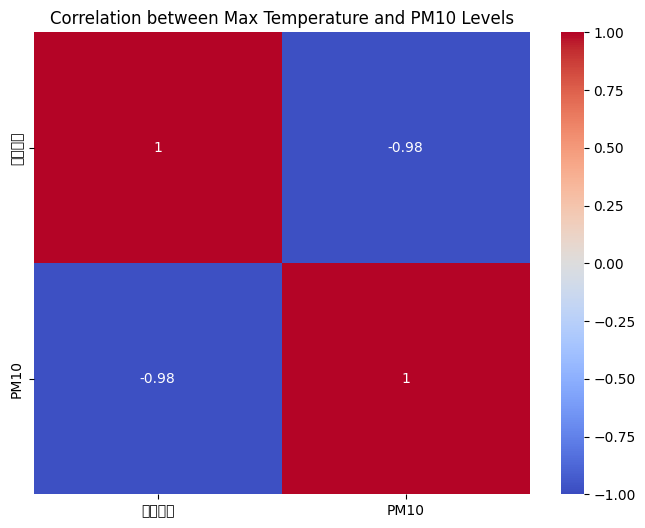

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the CSV files
gangnam_df = pd.read_csv('./강남구.csv')
pm_df = pd.read_csv('./converted_미세먼지.csv')

# Process the temperature data
gangnam_df['날짜'] = pd.to_datetime(gangnam_df['날짜'])
gangnam_df['YearMonth'] = gangnam_df['날짜'].dt.to_period('M')
monthly_max_temp = gangnam_df.groupby('YearMonth')['최고기온'].max().reset_index()
monthly_max_temp['YearMonth'] = monthly_max_temp['YearMonth'].astype(str)
monthly_max_temp['YearMonth'] = pd.to_datetime(monthly_max_temp['YearMonth'])

# Extract relevant columns for 강남구 from the 미세먼지 dataframe
gangnam_pm_df = pm_df[pm_df['구분(3)'] == '강남구']
gangnam_pm_df = gangnam_pm_df.drop(columns=['구분(1)', '구분(2)', '구분(3)', '구분(4)'])
gangnam_pm_df = gangnam_pm_df.melt(var_name='Month', value_name='PM10')
gangnam_pm_df['PM10'] = pd.to_numeric(gangnam_pm_df['PM10'].str.replace('*', ''), errors='coerce')
gangnam_pm_df['Month'] = pd.to_datetime(gangnam_pm_df['Month'], format='%Y.%m')
gangnam_pm_df.set_index('Month', inplace=True)

# Merge the temperature and PM10 data on the common 'YearMonth'
merged_df = pd.merge(monthly_max_temp, gangnam_pm_df, left_on='YearMonth', right_index=True)

# Calculate the correlation matrix
correlation_matrix = merged_df[['최고기온', 'PM10']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Max Temperature and PM10 Levels')
plt.show()


/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/yoonwogud/Desktop/Git/Python/Introduction_DataScience/bigdata_test/lib/python3.1

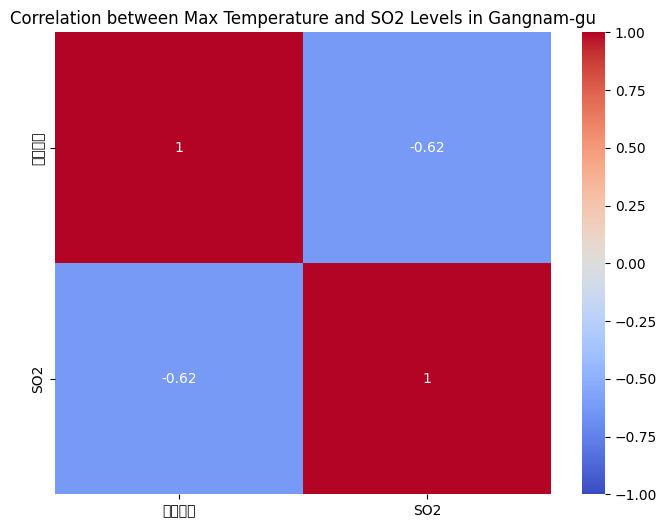

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV files
gangnam_df = pd.read_csv('./강남구.csv')
so2_df = pd.read_csv('./converted_아황산가스.csv')

# Process the temperature data
gangnam_df['날짜'] = pd.to_datetime(gangnam_df['날짜'])
gangnam_df['YearMonth'] = gangnam_df['날짜'].dt.to_period('M')
monthly_max_temp = gangnam_df.groupby('YearMonth')['최고기온'].max().reset_index()
monthly_max_temp['YearMonth'] = monthly_max_temp['YearMonth'].astype(str)
monthly_max_temp['YearMonth'] = pd.to_datetime(monthly_max_temp['YearMonth'])

# Extract relevant columns for 강남구 from the 아황산가스 dataframe
gangnam_so2_df = so2_df[so2_df['구분(3)'] == '강남구']
gangnam_so2_df = gangnam_so2_df.drop(columns=['구분(1)', '구분(2)', '구분(3)', '구분(4)'])
gangnam_so2_df = gangnam_so2_df.melt(var_name='Month', value_name='SO2')
gangnam_so2_df['SO2'] = pd.to_numeric(gangnam_so2_df['SO2'].str.replace('*', ''), errors='coerce')
gangnam_so2_df['Month'] = pd.to_datetime(gangnam_so2_df['Month'], format='%Y.%m')
gangnam_so2_df.set_index('Month', inplace=True)

# Merge the temperature and SO2 data on the common 'YearMonth'
merged_df_so2 = pd.merge(monthly_max_temp, gangnam_so2_df, left_on='YearMonth', right_index=True)

# Calculate the correlation matrix
correlation_matrix_so2 = merged_df_so2[['최고기온', 'SO2']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_so2, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Max Temperature and SO2 Levels in Gangnam-gu')
plt.show()


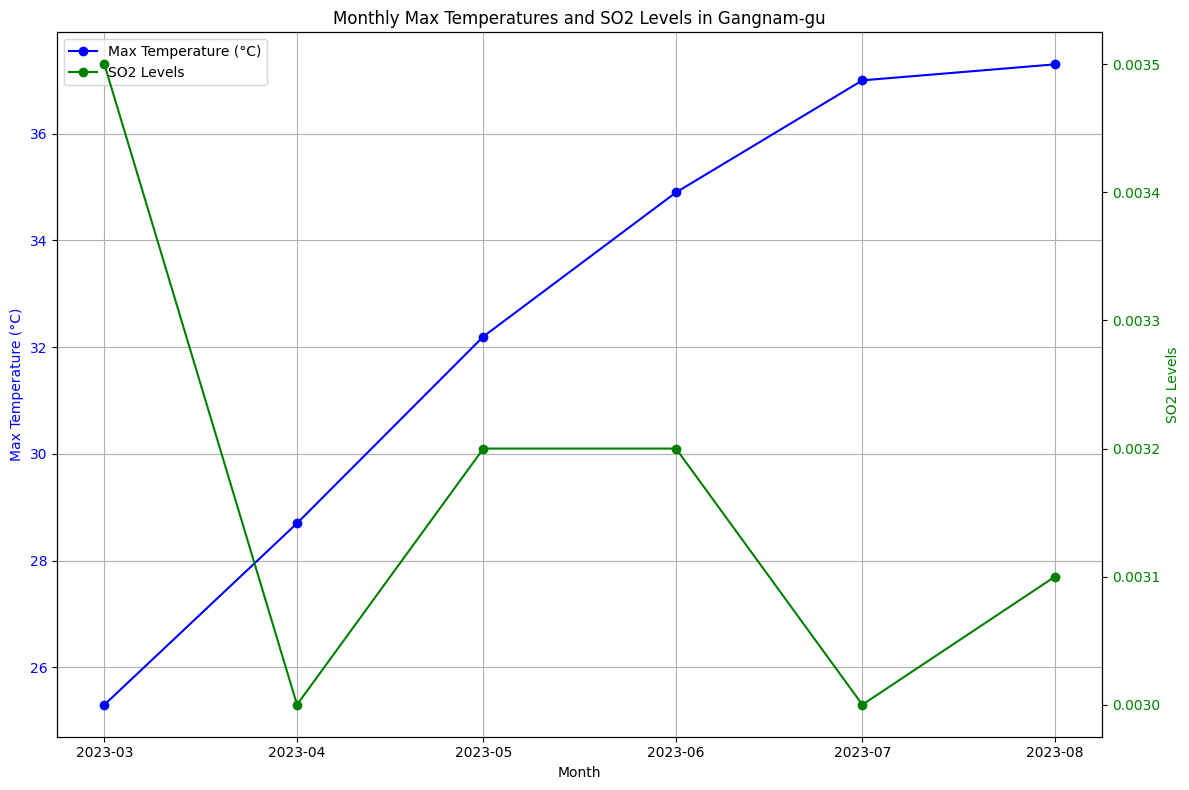

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV files
gangnam_df = pd.read_csv('./강남구.csv')
so2_df = pd.read_csv('./converted_아황산가스.csv')

# Process the temperature data
gangnam_df['날짜'] = pd.to_datetime(gangnam_df['날짜'])
gangnam_df['YearMonth'] = gangnam_df['날짜'].dt.to_period('M')
monthly_max_temp = gangnam_df.groupby('YearMonth')['최고기온'].max().reset_index()
monthly_max_temp['YearMonth'] = monthly_max_temp['YearMonth'].astype(str)
monthly_max_temp['YearMonth'] = pd.to_datetime(monthly_max_temp['YearMonth'])

# Extract relevant columns for 강남구 from the 아황산가스 dataframe
gangnam_so2_df = so2_df[so2_df['구분(3)'] == '강남구']
gangnam_so2_df = gangnam_so2_df.drop(columns=['구분(1)', '구분(2)', '구분(3)', '구분(4)'])
gangnam_so2_df = gangnam_so2_df.melt(var_name='Month', value_name='SO2')
gangnam_so2_df['SO2'] = pd.to_numeric(gangnam_so2_df['SO2'].str.replace('*', ''), errors='coerce')
gangnam_so2_df['Month'] = pd.to_datetime(gangnam_so2_df['Month'], format='%Y.%m')
gangnam_so2_df.set_index('Month', inplace=True)

# Merge the temperature and SO2 data on the common 'YearMonth'
merged_df_so2 = pd.merge(monthly_max_temp, gangnam_so2_df, left_on='YearMonth', right_index=True)

# Create the combined plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plotting the temperature data
ax1.plot(merged_df_so2['YearMonth'], merged_df_so2['최고기온'], marker='o', linestyle='-', color='b', label='Max Temperature (°C)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Max Temperature (°C)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Creating a second y-axis for the SO2 data
ax2 = ax1.twinx()
ax2.plot(merged_df_so2['YearMonth'], merged_df_so2['SO2'], marker='o', linestyle='-', color='g', label='SO2 Levels')
ax2.set_ylabel('SO2 Levels', color='g')
ax2.tick_params(axis='y', labelcolor='g')

# Adding title and grid
plt.title('Monthly Max Temperatures and SO2 Levels in Gangnam-gu')
ax1.grid(True)

# Adding legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()


강남구의 미세먼지와 온도 상관관계 / 음의 상관관계 보유